In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
import struct
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from pathlib import Path


In [2]:
data = get_data()
config, config_str = get_hmc_config(find_min = False, bias = "unified", cap = False, temp = True, umbrella = True)
find_min_config, config_find_min_str = get_hmc_config(find_min = True)
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))
print(config["nl"])

51


In [3]:
base_dir = Path.cwd()

samples = (base_dir / f"../../../../output/age_depth_OPES/samples_{config_str}.npy").resolve()
energy_values = (base_dir / f"../../../../output/age_depth_OPES/energy_{config_str}.npy").resolve()
bias_values = (base_dir / f"../../../../output/age_depth_OPES/bias_{config_str}.npy").resolve()
resampled_samples = (base_dir / f"../../../../output/age_depth_OPES/resamp_{config_str}.npy").resolve()

samples = np.load(samples)
energy_values = np.load(energy_values)
bias_values = np.load(bias_values)
resampled_samples = np.load(resampled_samples)


In [4]:
print(energy_values)

[[138.87378297 147.55256742 153.38432628 ... 145.48602686 146.01283489
  150.42931796]
 [130.89917473 130.89917473 130.89917473 ... 121.39020345 126.09655485
  133.92651308]
 [143.69375883 143.18704223 150.17875079 ... 111.36542242 121.90257079
  120.20012686]
 [131.42593477 144.96824148 144.93948511 ... 123.26326821 126.63669029
  118.20283272]
 [129.47864691 145.8977704  136.89571599 ... 110.98753866 108.40020336
  111.88080827]]


In [5]:
nl = config["nl"] if config["nl"] != None else 1
nl2 = config["nl"] if config["npc"] == 2 else 1
nt = config["nt"] if config["nt"] != None else 1
temp_colors = plt.cm.viridis(np.linspace(0,1, nt))
print(config["nl"])


51


In [6]:
base_dir = Path.cwd()

files = [(base_dir / f"../../../../output/age_depth_OPES/deltaF_chain{i}_{config_str}.bin").resolve() for i in range(config["nch"])]

stride = 10000
deltaF = []

for f in files:
    print(f)
    dF_data = np.fromfile(f, dtype=np.float64)
    print(np.shape(dF_data))
    # reshape to full dimensions first
    dF_data = dF_data.reshape(int(config["ns"]/stride), nl, nl2, nt)
    # take every 10th element along the first axis
    deltaF.append(dF_data)

deltaF = np.array(deltaF)
print(deltaF.shape)

C:\Users\hanna\Desktop\PhD\Bacon\output\age_depth_OPES\deltaF_chain0_N49_H100_dc2_dt0.005_ns1000000_co10_ndt10_nHMC10_nch5_a1.5_b0.21_s0.4_dE50_d40_sb-10_eb10_nl51_sbt1_ebt5_nt5_npc1.bin
(25500,)
C:\Users\hanna\Desktop\PhD\Bacon\output\age_depth_OPES\deltaF_chain1_N49_H100_dc2_dt0.005_ns1000000_co10_ndt10_nHMC10_nch5_a1.5_b0.21_s0.4_dE50_d40_sb-10_eb10_nl51_sbt1_ebt5_nt5_npc1.bin
(25500,)
C:\Users\hanna\Desktop\PhD\Bacon\output\age_depth_OPES\deltaF_chain2_N49_H100_dc2_dt0.005_ns1000000_co10_ndt10_nHMC10_nch5_a1.5_b0.21_s0.4_dE50_d40_sb-10_eb10_nl51_sbt1_ebt5_nt5_npc1.bin
(25500,)
C:\Users\hanna\Desktop\PhD\Bacon\output\age_depth_OPES\deltaF_chain3_N49_H100_dc2_dt0.005_ns1000000_co10_ndt10_nHMC10_nch5_a1.5_b0.21_s0.4_dE50_d40_sb-10_eb10_nl51_sbt1_ebt5_nt5_npc1.bin
(25500,)
C:\Users\hanna\Desktop\PhD\Bacon\output\age_depth_OPES\deltaF_chain4_N49_H100_dc2_dt0.005_ns1000000_co10_ndt10_nHMC10_nch5_a1.5_b0.21_s0.4_dE50_d40_sb-10_eb10_nl51_sbt1_ebt5_nt5_npc1.bin
(25500,)
(5, 100, 51, 1, 5)


In [7]:
print("Reweighting energies for each temp\n")

if nt > 1:
    factors = np.arange(nt) / (nt - 1)
else:
    factors = np.array([0.0])

temp_centers = config["sbt"] + ((config["ebt"] - config["sbt"]) * factors)# * (config["ebt"] / config["sbt"]) ** factors

# Compute betas
betas = 1.0 / temp_centers

# Initial beta
beta0 = 1.0 / config["sbt"]
energy_samples = []
weights = []

for j in range(config["nt"]):
    temp_energy_samples = []
    weights = np.exp(-(betas[j] - beta0) * energy_values + bias_values)
    for i in range(config["nch"]):
        weights_i = weights[i, config["co"]:] / sum(weights[i, config["co"]:])
        indices = np.random.choice(
            np.arange(config["co"], len(weights_i) + config["co"]),
            size=int(len(weights_i)),
            replace=True,
            p=weights_i,
        )
        print(f"Chain {i} done resampling")
        temp_energy_samples.append(energy_values[i, indices])
    energy_samples.append(temp_energy_samples)
        
energy_samples = np.array(energy_samples)
print(np.shape(energy_samples))

Reweighting energies for each temp

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
(5, 5, 999990)


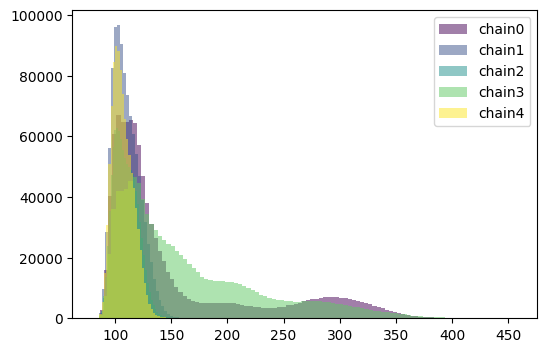

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
plt.legend()
plt.show()   

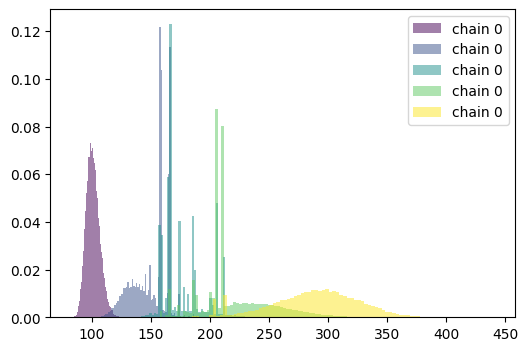

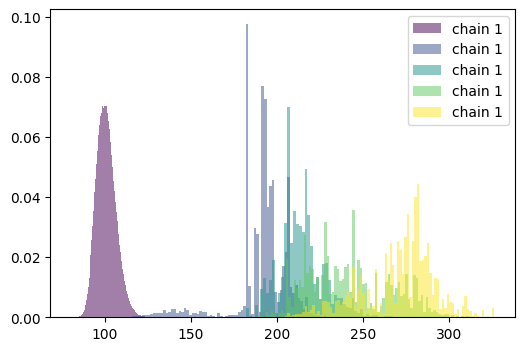

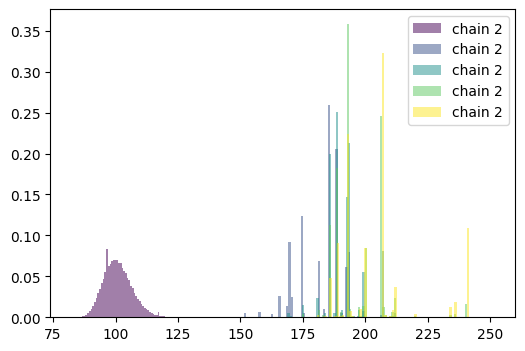

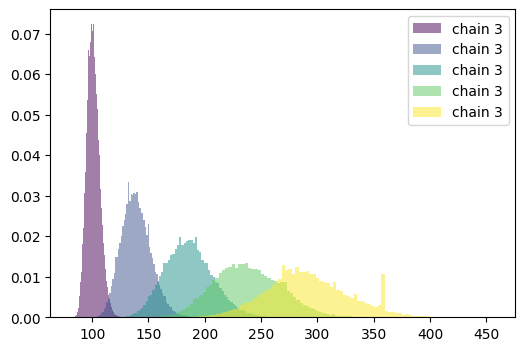

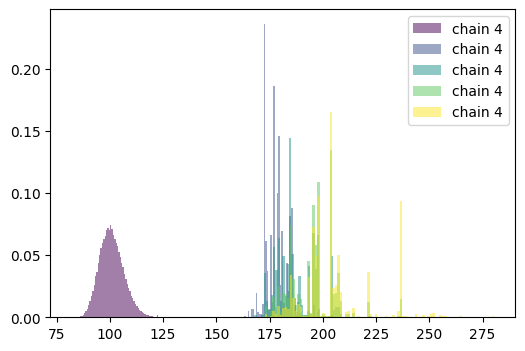

In [9]:
limit_grid = np.linspace(80, 190, 100)
bin_grid = limit_grid[:-1]

for k in range(config["nch"]):
    fig, ax = plt.subplots(figsize=(6, 4))
    for j in range(config["nt"]):
        # bin_values = np.zeros_like(bin_grid)
        # weights = np.exp(-(betas[j] - beta0) * energy_values[k, :] + bias_values[k, :])
        # for bin_idx in range(len(bin_grid)):
        #     for i, e in enumerate(energy_values[k, :]):
        #         if e > limit_grid[bin_idx] and e < limit_grid[bin_idx + 1]:
        #             bin_values[bin_idx] += weights[i]
        # print(sum(weights))
        # bin_values /= sum(weights)
        # # print(bin_values)
        # ax.plot(bin_grid + ((190-80)/100), bin_values, color = temp_colors[j])
        ax.hist(energy_samples[j, k, :], bins = 100, color = temp_colors[j], label = f"chain {k}", alpha = 0.5, density = True)
    plt.legend()
    plt.savefig(f"../../../../pics/temp_pic_chain_{k}_{config_str}.jpg")
    plt.show()





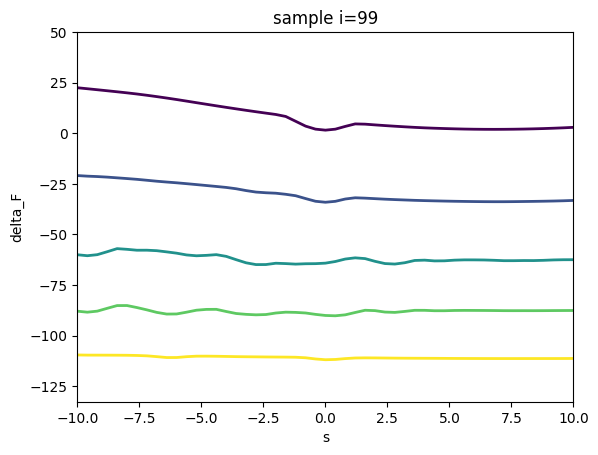

In [11]:
%matplotlib inline
if (not (config["npc"] == None)):

    if config["npc"] == 2:
        xcoords = np.linspace(config["sb"], config["eb"], config["nl"])
        ycoords = np.linspace(config["sb"], config["eb"], config["nl"])

        X, Y = np.meshgrid(xcoords, ycoords)

        for i in range(config["nch"]):
            last_delta_F = np.squeeze(deltaF[i, -1, :, :, 9])
            indices = np.unravel_index(np.argmin(last_delta_F), last_delta_F.shape)
            print(deltaF[i, :, :, 0])
            print(f"Chain {i} min deltaF at: {indices}")
            print(xcoords[indices[0]])
            print(ycoords[indices[1]])
            print(f"{i}\n")
            print(last_delta_F[last_delta_F<50])
            plt.figure(figsize=(6,5))
            pcm = plt.pcolormesh(X, Y, last_delta_F.T, shading='auto', cmap='viridis') # This looks flipped, could be the plotting, but could also be the indexing.
            plt.colorbar(pcm, label='Value')
            plt.xlabel('X coordinate')
            plt.ylabel('Y coordinate')
            plt.title('2D Plot with coordinates')
            plt.show()
    if config["npc"] == 1:
        xcoords = np.linspace(config["sb"], config["eb"], config["nl"])

        fig, ax = plt.subplots()

        lines = []

        for j in range(nt):
            line, = ax.plot([], [], lw=2, label=f"T{j}", color = temp_colors[j])
            lines.append(line)
        ax.set_xlim(config["sb"], config["eb"])
        ax.set_ylim(np.min(deltaF), np.max(deltaF))

        ax.set_xlabel("s")
        ax.set_ylabel("delta_F")

        def update(frame):
            i = frame
            for j in range(nt):
                sample_delta_F = np.squeeze(deltaF[0, i, :, 0, j])
                lines[j].set_data(xcoords, sample_delta_F)
            ax.set_title(f"sample i={i}")
            return lines,
    
        frames = int(config["ns"]/stride)  # number of frames
        ani = FuncAnimation(fig, update, frames=frames, blit=False, interval=100, repeat = False)
        ani.save(f"animation_{config_str}.gif", writer="pillow", fps=5)

        plt.show()
elif config["nt"]>1 and nl == 1 and nl2 == 1:
    fig, ax = plt.subplots()

    x = np.linspace(0, int(config["ns"]/stride), int(config["ns"]/stride))
    chain = 0
    for k in range(config["nt"]):
        sample_delta_F = np.squeeze(deltaF[chain, :, 0, 0, k])
        ax.plot(x, sample_delta_F, '*-', color = temp_colors[k], label = f"{temp_centers[k]}")

    plt.legend()
    plt.show()

In [12]:
# starting_points = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_min_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
# starting_energies = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/Emin_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
starting_energies_path = (base_dir / f"../../../../output/age_depth_OPES/Emin_{config_find_min_str}.npy").resolve()
starting_energies = np.load(starting_energies_path)
starting_points_path = (base_dir / f"../../../../output/age_depth_OPES/samples_min_{config_find_min_str}.npy").resolve()
starting_points= np.load(starting_points_path)
print(starting_energies)

[  152.73920257   152.92895937   136.23130611   153.73228631
   132.68658913   141.38433134   128.18740446   142.47017464
   817.34767152   148.27296444   150.09028116  3117.47913517
   135.48474428   134.92941019   144.5301032    147.26855042
   129.24288744   133.24481257   127.74279368   956.35993394
   122.77644541   126.44343682   128.01657656   135.45367
   125.32845059   135.67092153   121.57449816   120.91327681
   137.75892701   147.3178387    131.76337012   143.19643748
   138.99355402   144.68494645 20562.66663404  2027.71907329
   144.46153821   142.67364668   154.2323473    141.71307192
   126.36579963   146.78674942   152.04564093   148.11419149
   134.98735057   150.1391595    144.62184712   136.63747083
   126.71486604   144.05173375   134.81880301   140.2471813
   144.52746693   122.81312542   158.15524081   144.9659742
   138.50402334   133.97053177 19383.61378112   151.11614227
   142.47977679   131.75484051   194.49440503   127.75120524
   140.1125148    127.5641680

In [12]:
# print(starting_points)
# # print(np.sort(starting_energies))
# sp_mean = np.mean(starting_points, axis = 0)
# sp = starting_points-sp_mean
# cov = np.cov(sp, rowvar=False)
# eigenvalues, eigenvectors = np.linalg.eigh(cov)

# idx = np.argsort(eigenvalues)[::-1]
# eigenvalues = eigenvalues[idx]
# eigenvectors = eigenvectors[:, idx]

# pc1 = eigenvectors[:, 0]
# pc2 = eigenvectors[:, 1]

# print(eigenvalues)
# print(np.sum(eigenvalues[0:4])/np.sum(eigenvalues))
# var_ratio = eigenvalues[0] / np.sum(eigenvalues)
# var2_ratio = eigenvalues[1] / np.sum(eigenvalues)
# print("Main direction at problem:", pc1[20:25])
# print(np.abs(pc1) > 0.1)
# print("Main direction:", pc1[np.abs(pc1) > 0.1])

# print(np.linalg.norm(pc1))
# print(30 * np.sum(pc1[pc1>0]))
# print(30 * np.sum(pc1[pc1<0]))

In [13]:
energy_idx = np.argsort(starting_energies) # might bug if there are not enough starting points.
sp_smallest = starting_points[energy_idx][:20]
sp_mean= np.mean(sp_smallest, axis = 0)

sp_centered = sp_smallest-sp_mean
cov = np.cov(sp_centered, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

energies = starting_energies[idx]
sp_energies = energies[:config["nch"]]
sp = sp_smallest[:config["nch"], :]

C:\Users\hanna\AppData\Local\Temp\ipykernel_20464\1855283856.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"../../../../pics/trajectory_{config_str}.jpg")
c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


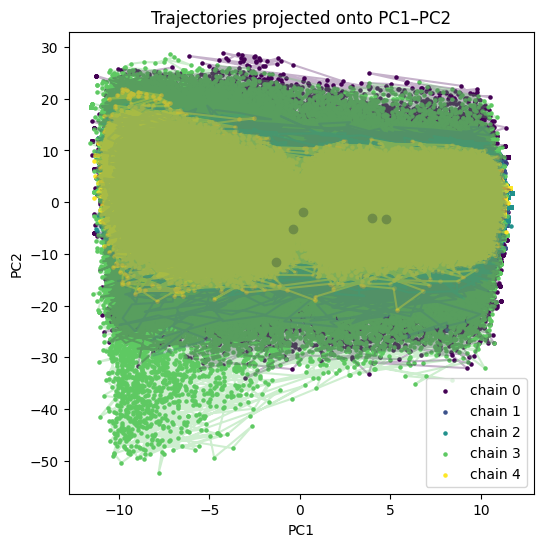

In [14]:
proj = []
for chain in range(samples.shape[0]):
    traj = samples[chain]
    traj_centered = traj - sp_mean
    coords = np.stack([traj_centered @ pc1,
                       traj_centered @ pc2], axis=1) # This should be the same as what i get when i print in C, maybe the indexing becomes wrong when i send in the pcs?
    proj.append(coords)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

for chain, coords in enumerate(proj):
    ax.plot(coords[:,0], coords[:,1], alpha=0.3, color=colors[chain])
    ax.scatter(coords[:,0], coords[:,1], s=5, color=colors[chain], label=f"chain {chain}")

ax.scatter(sp @ pc1, sp @ pc2, color = 'black', marker = 'o')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectories projected onto PC1–PC2") # Something is weird, adding the exploration in pc2 makes it explore worse in pc1, something is still wrong.
ax.legend()
plt.savefig(f"../../../../pics/trajectory_{config_str}.jpg")
plt.show()

In [15]:
print(np.shape(resampled_samples))
print(np.shape(samples))

(5, 999990, 49)
(5, 1000000, 49)


In [16]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [17]:
print(energy_values)

[[138.87378297 147.55256742 153.38432628 ... 145.48602686 146.01283489
  150.42931796]
 [130.89917473 130.89917473 130.89917473 ... 121.39020345 126.09655485
  133.92651308]
 [143.69375883 143.18704223 150.17875079 ... 111.36542242 121.90257079
  120.20012686]
 [131.42593477 144.96824148 144.93948511 ... 123.26326821 126.63669029
  118.20283272]
 [129.47864691 145.8977704  136.89571599 ... 110.98753866 108.40020336
  111.88080827]]


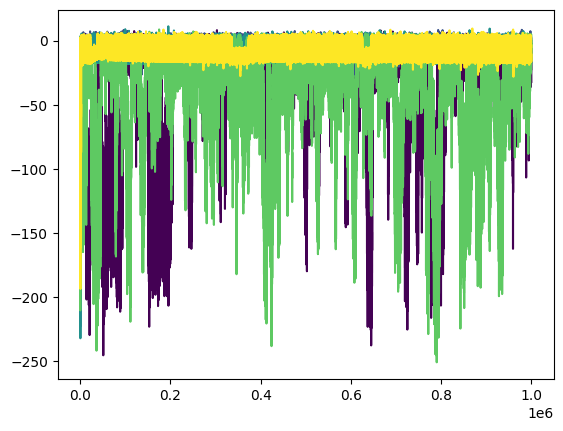

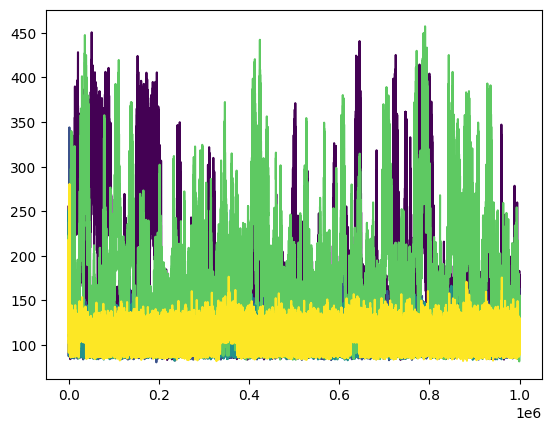

In [18]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.savefig(f"../../../../pics/bias_{config_str}.jpg")
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:], color = colors[i])
plt.savefig(f"../../../../pics/energy_{config_str}.jpg")
plt.show()


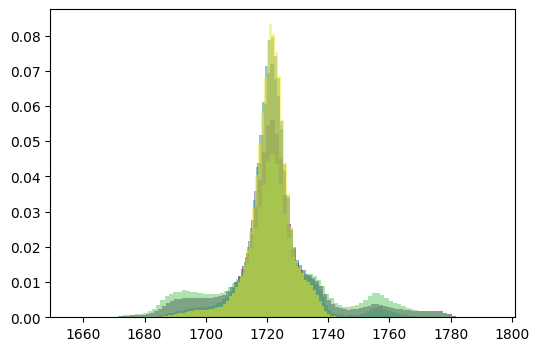

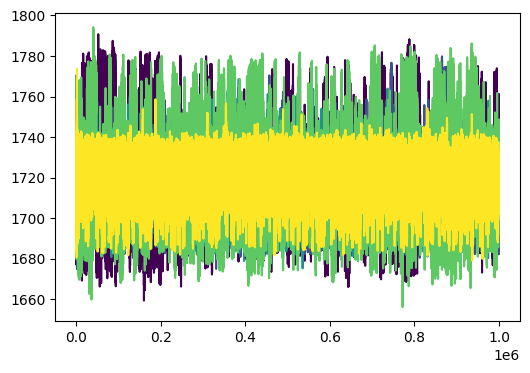

In [ ]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :22], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"../../../../pics/sampling_along_depth44_{config_str}.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

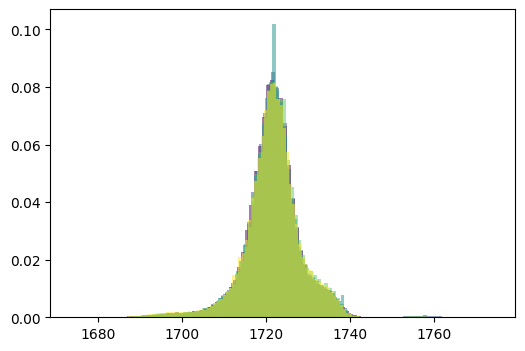

In [ ]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :22], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"../../../../pics/resampling_along_depth44_{config_str}.jpg")
plt.show()

In [23]:
resampled_samples = resampled_samples[:,::100,:]

In [24]:
print(np.max(bias_values))

11.075691567410907


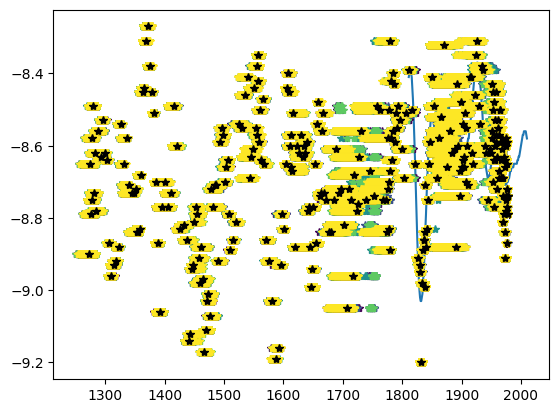

In [25]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"][:], data["d18O_reference"][:])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [26]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    3.00  0.50    2.00     3.88       0.00     0.00  49507.19  49973.44   
x[1]    4.27  1.86    1.04     7.91       0.01     0.01  49338.11  49474.04   
x[2]    2.90  1.66    0.10     5.75       0.01     0.01  49560.42  49700.34   
x[3]   11.33  2.24    7.17    15.50       0.01     0.01  50518.93  49851.11   
x[4]    4.73  2.25    0.61     8.64       0.01     0.01  49584.54  49277.34   
x[5]    8.96  5.03    0.65    17.47       0.02     0.01  48709.24  49353.41   
x[6]    5.38  3.73    0.02    12.09       0.02     0.02  49543.15  47407.96   
x[7]    5.18  3.73    0.02    12.01       0.02     0.01  50155.72  49915.35   
x[8]    5.00  3.57    0.01    11.51       0.02     0.01  51161.56  50358.26   
x[9]    5.28  3.84    0.01    12.38       0.02     0.01  49811.39  49031.02   
x[10]   4.43  3.00    0.01     9.67       0.01     0.01  47779.67  49683.00   
x[11]   5.63  4.01    0.11    13.53       0.02     0

In [27]:
depths = np.sort(np.hstack((0, data["d18O_depths"])))
ages = np.flip(np.hstack((data["theta"], data["true_ages_D18O"]))) # why are they not sorted correctly?
# print(depths)
# print(ages)
sed_rates = [0]
theta = data["theta"]

pre_age = theta
pre_depth = 0
for i in range(1, config["N"] + 1):
    idx = np.searchsorted(depths, config["cs"][i])
    # print(np.sort(depths))
    # print(config["cs"][i])
    # print(idx)
    if idx < len(depths):
        upper_depth = depths[idx - 1]
        age = ages[idx - 1] + ((ages[idx] - ages[idx - 1])/(depths[idx] - depths[idx - 1]))*(config["cs"][i] - depths[idx-1])
        sed_rates.append((pre_age - age) / (config["cs"][i] - config["cs"][i-1]))
        pre_age = age
    else:
        sed_rates.append(config["a"] / config["b"])


print(sed_rates)
exp_ages = theta - np.cumsum(sed_rates) * config["dc"]
print(exp_ages)
print(np.max(sed_rates))

[0, np.float64(3.006759999999988), np.float64(4.9418212499999505), np.float64(5.384768750000065), np.float64(7.547132926829237), np.float64(6.108668235961432), np.float64(4.87410121816174), np.float64(3.6105173864893922), np.float64(2.4293302325582027), np.float64(3.3648181818181935), np.float64(7.072172515856226), np.float64(10.3161045404208), np.float64(7.081804761904791), np.float64(3.0009575000000006), np.float64(2.6977574999999576), np.float64(7.454521363636328), np.float64(9.259703636363676), np.float64(5.120382727272744), np.float64(2.676350606060601), np.float64(1.7478466666667005), np.float64(1.5238799999998962), np.float64(7.479033333333421), np.float64(14.450147517730477), np.float64(10.678402482269497), np.float64(8.874633333333287), np.float64(8.593689716312097), np.float64(5.156382978723392), np.float64(4.6246155163467035), np.float64(4.668535121951227), np.float64(5.197047500000013), np.float64(6.867283928571361), np.float64(3.7729122448979275), np.float64(3.196341326530

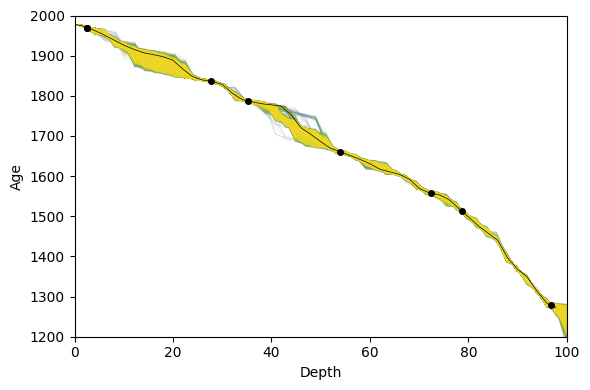

In [ ]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
# i=4
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     if i != config["pidx"]:
#         ax.axvline(x=c, color='k', linestyle='--')
#     else:
#         ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
# plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(config["cs"], exp_ages, color = 'r', linewidth = 0.5)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.plot(data["d18O_depths"], data["true_ages_D18O"], color = 'k', linewidth=0.5)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"../../../../pics/age_depth_chain_{i}_{config_str}.jpg")
plt.show()